In [ ]:
!pip install numpy pandas plotly matplotlib seaborn missingno folium dash dash_core_components dash_html_components

Importation des librairies et préparation de l'affichage

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tarfile
import os
from functools import reduce

# Configuring display settings
plt.rcParams['figure.figsize'] = (12, 9)
sns.set()
sns.set_context('talk')
np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings("ignore", category=FutureWarning)


Visualisation et exploration des données

In [48]:

employee_survey_data_file_path = os.path.join('employee_survey_data.csv')
general_data_file_path = os.path.join('general_data.csv')
manager_survey_data_file_path = os.path.join('manager_survey_data.csv')
in_time_data_file_path = os.path.join('in_time.csv')
out_time_data_file_path = os.path.join('out_time.csv')
# Load the dataset
employee_survey_data = pd.read_csv(employee_survey_data_file_path)
general_data = pd.read_csv(general_data_file_path)
manager_survey_data = pd.read_csv(manager_survey_data_file_path)
in_time_data = pd.read_csv(in_time_data_file_path)
out_time_data = pd.read_csv(out_time_data_file_path)

Compréhension du dataset employee_data

In [49]:
employee_survey_data.head()
employee_survey_data.info()
employee_survey_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 137.9 KB


,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
count,4410.00,4385.00,4390.00,4372.00
mean,2205.50,2.72,2.73,2.76
std,1273.20,1.09,1.10,0.71
min,1.00,1.00,1.00,1.00
25%,1103.25,2.00,2.00,2.00
50%,2205.50,3.00,3.00,3.00
75%,3307.75,4.00,4.00,3.00
max,4410.00,4.00,4.00,4.00


Compréhension du dataset general_data

In [10]:
general_data.head()
general_data.info()
general_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
count,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4391.00,4410.00,4410.00,4410.00,4401.00,4410.00,4410.00,4410.00,4410.00
mean,36.92,9.19,2.91,1.00,2205.50,2.06,65029.31,2.69,15.21,8.00,0.79,11.28,2.80,7.01,2.19,4.12
std,9.13,8.11,1.02,0.00,1273.20,1.11,47068.89,2.50,3.66,0.00,0.85,7.78,1.29,6.13,3.22,3.57
min,18.00,1.00,1.00,1.00,1.00,1.00,10090.00,0.00,11.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,30.00,2.00,2.00,1.00,1103.25,1.00,29110.00,1.00,12.00,8.00,0.00,6.00,2.00,3.00,0.00,2.00
50%,36.00,7.00,3.00,1.00,2205.50,2.00,49190.00,2.00,14.00,8.00,1.00,10.00,3.00,5.00,1.00,3.00
75%,43.00,14.00,4.00,1.00,3307.75,3.00,83800.00,4.00,18.00,8.00,1.00,15.00,3.00,9.00,3.00,7.00
max,60.00,29.00,5.00,1.00,4410.00,5.00,199990.00,9.00,25.00,8.00,3.00,40.00,6.00,40.00,15.00,17.00


Compréhension du dataset manager_survey_data

In [11]:
manager_survey_data.head()
manager_survey_data.info()
manager_survey_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   EmployeeID         4410 non-null   int64
 1   JobInvolvement     4410 non-null   int64
 2   PerformanceRating  4410 non-null   int64
dtypes: int64(3)
memory usage: 103.5 KB


,EmployeeID,JobInvolvement,PerformanceRating
count,4410.00,4410.00,4410.00
mean,2205.50,2.73,3.15
std,1273.20,0.71,0.36
min,1.00,1.00,3.00
25%,1103.25,2.00,3.00
50%,2205.50,3.00,3.00
75%,3307.75,3.00,3.00
max,4410.00,4.00,4.00


Objet de l'étude : Le salarié a-t-il quiité l'entreprise durant l'année 2016 ?

In [16]:
general_data['Attrition'].value_counts()

Attrition
No     3699
Yes     711
Name: count, dtype: int64

Nettoyage des valeurs manquantes de employee_survey_data

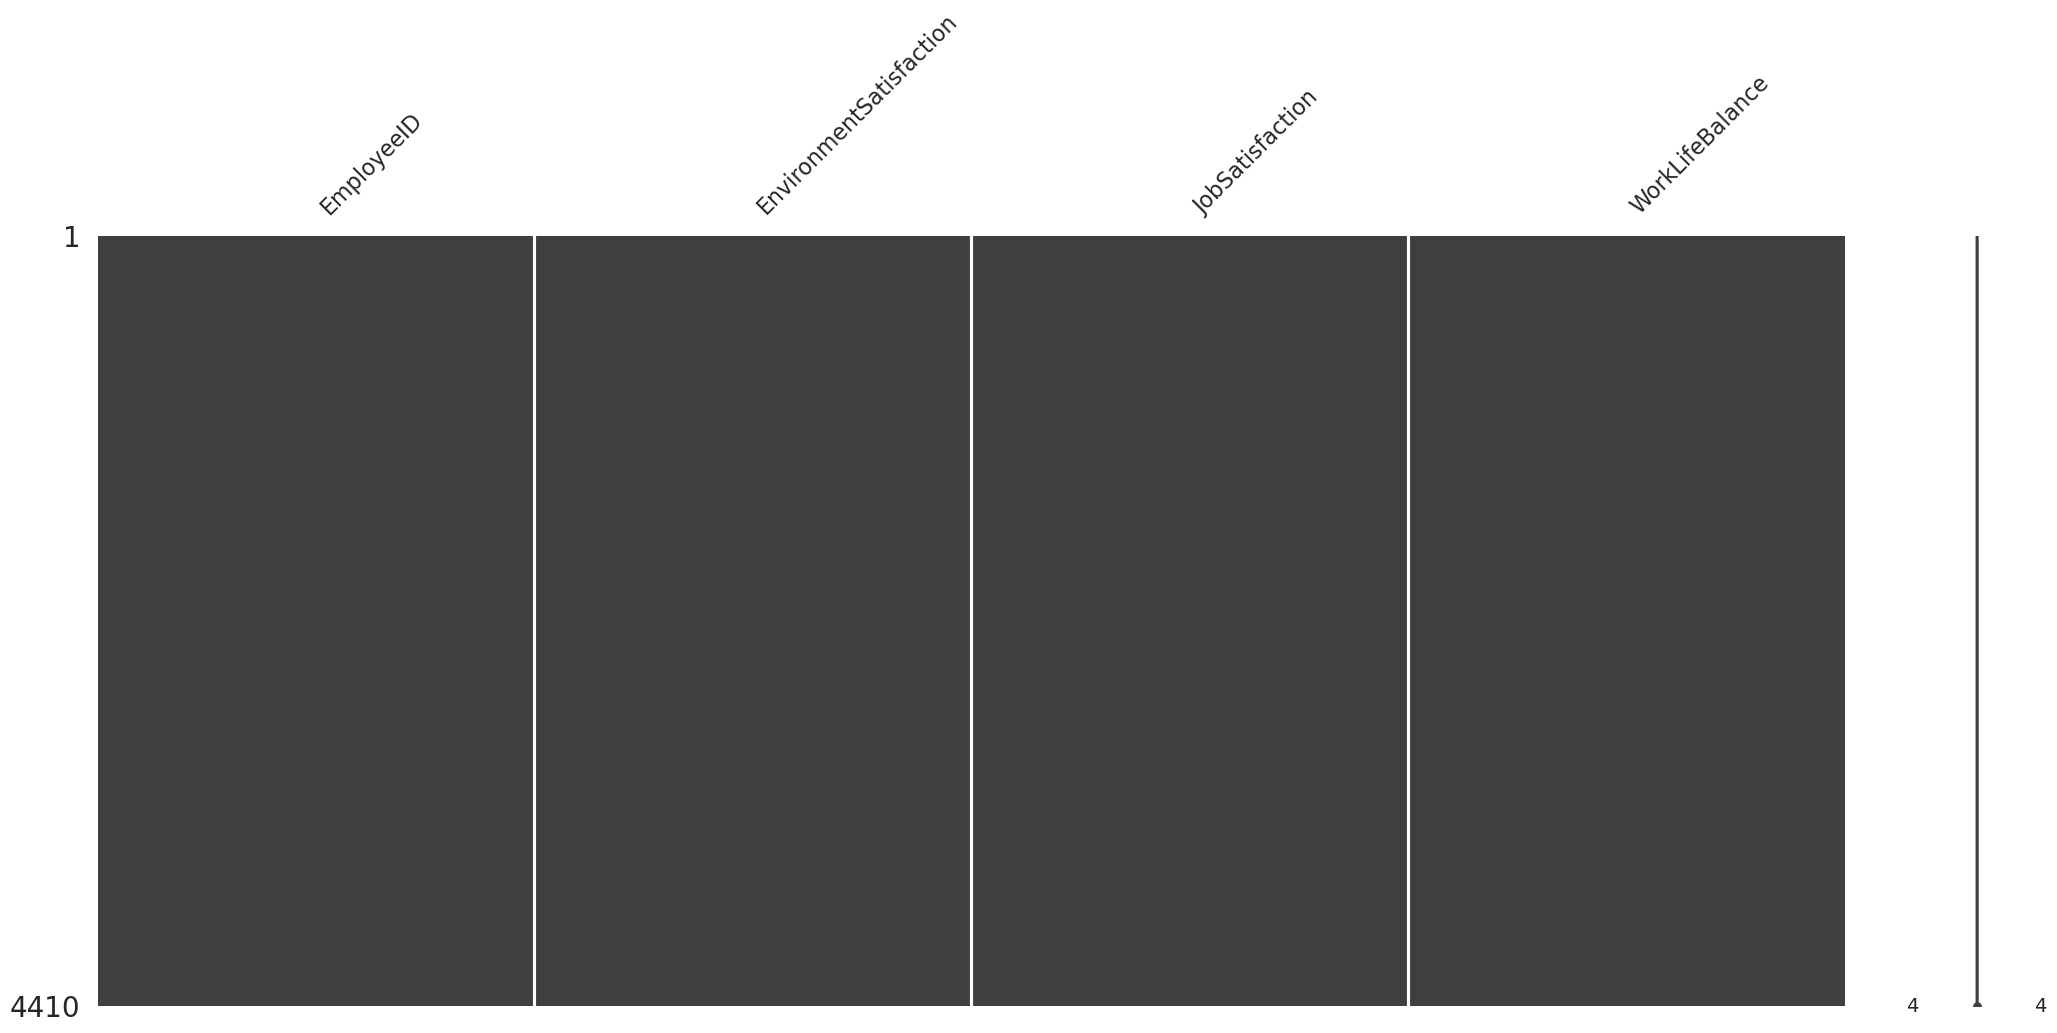

EmployeeID                 0
EnvironmentSatisfaction    0
JobSatisfaction            0
WorkLifeBalance            0
dtype: int64

In [18]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing data
msno.matrix(employee_survey_data)
plt.show()

# Impute missing values
# For numerical columns, use median imputation
numerical_columns = employee_survey_data.select_dtypes(include=['float64', 'int64']).columns
employee_survey_data[numerical_columns] = employee_survey_data[numerical_columns].fillna(employee_survey_data[numerical_columns].median())

# For categorical columns, use mode imputation
categorical_columns = employee_survey_data.select_dtypes(include=['object']).columns

# Verify that there are no more missing values
employee_survey_data.isnull().sum()


Traitement des valeurs manquantes de general_data

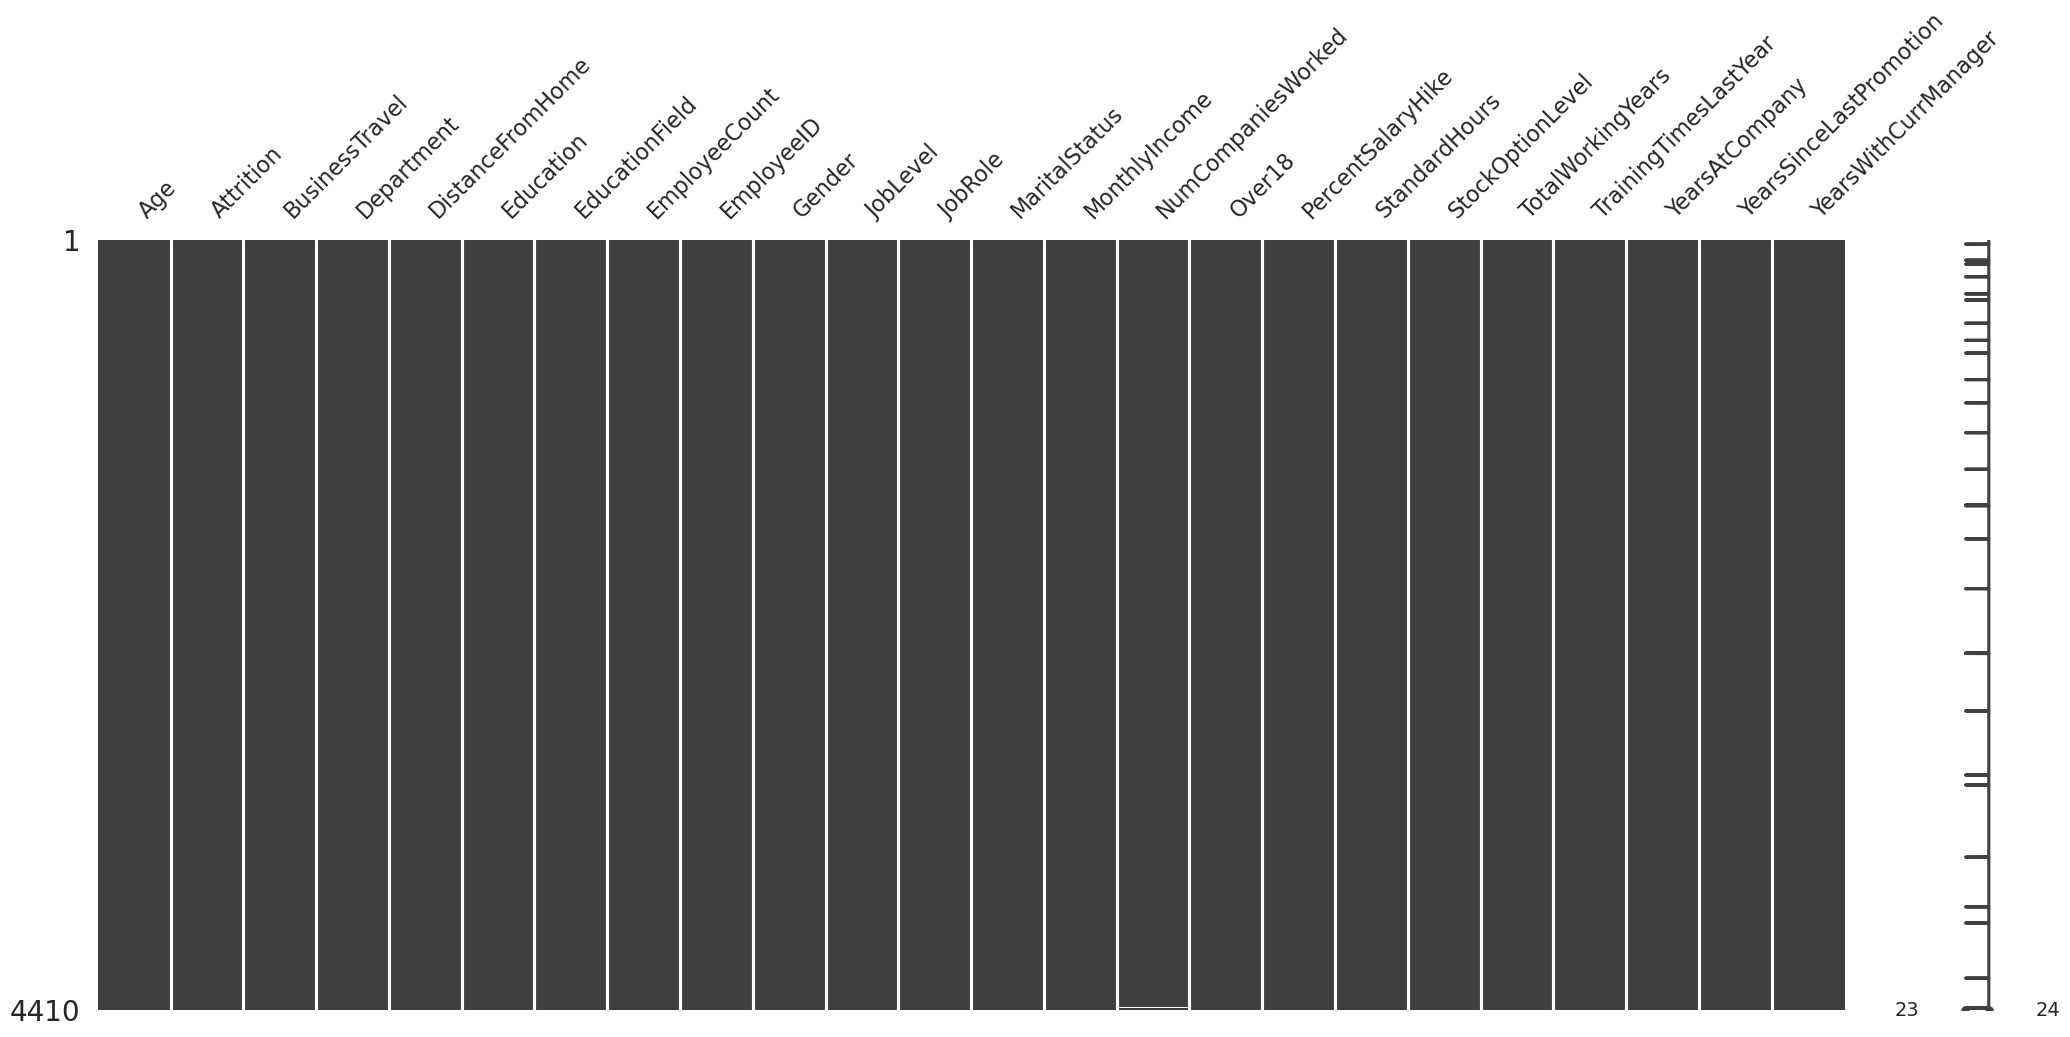

Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeCount              0
EmployeeID                 0
Gender                     0
JobLevel                   0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
Over18                     0
PercentSalaryHike          0
StandardHours              0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

In [19]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing data
msno.matrix(general_data)
plt.show()

# Impute missing values
# For numerical columns, use median imputation
numerical_columns = general_data.select_dtypes(include=['float64', 'int64']).columns
general_data[numerical_columns] = general_data[numerical_columns].fillna(general_data[numerical_columns].median())

# For categorical columns, use mode imputation
categorical_columns = general_data.select_dtypes(include=['object']).columns
general_data[categorical_columns] = general_data[categorical_columns].fillna(general_data[categorical_columns].mode().iloc[0])

# Verify that there are no more missing values
general_data.isnull().sum()


Traitement des valeurs manquantes de manager_survey_data

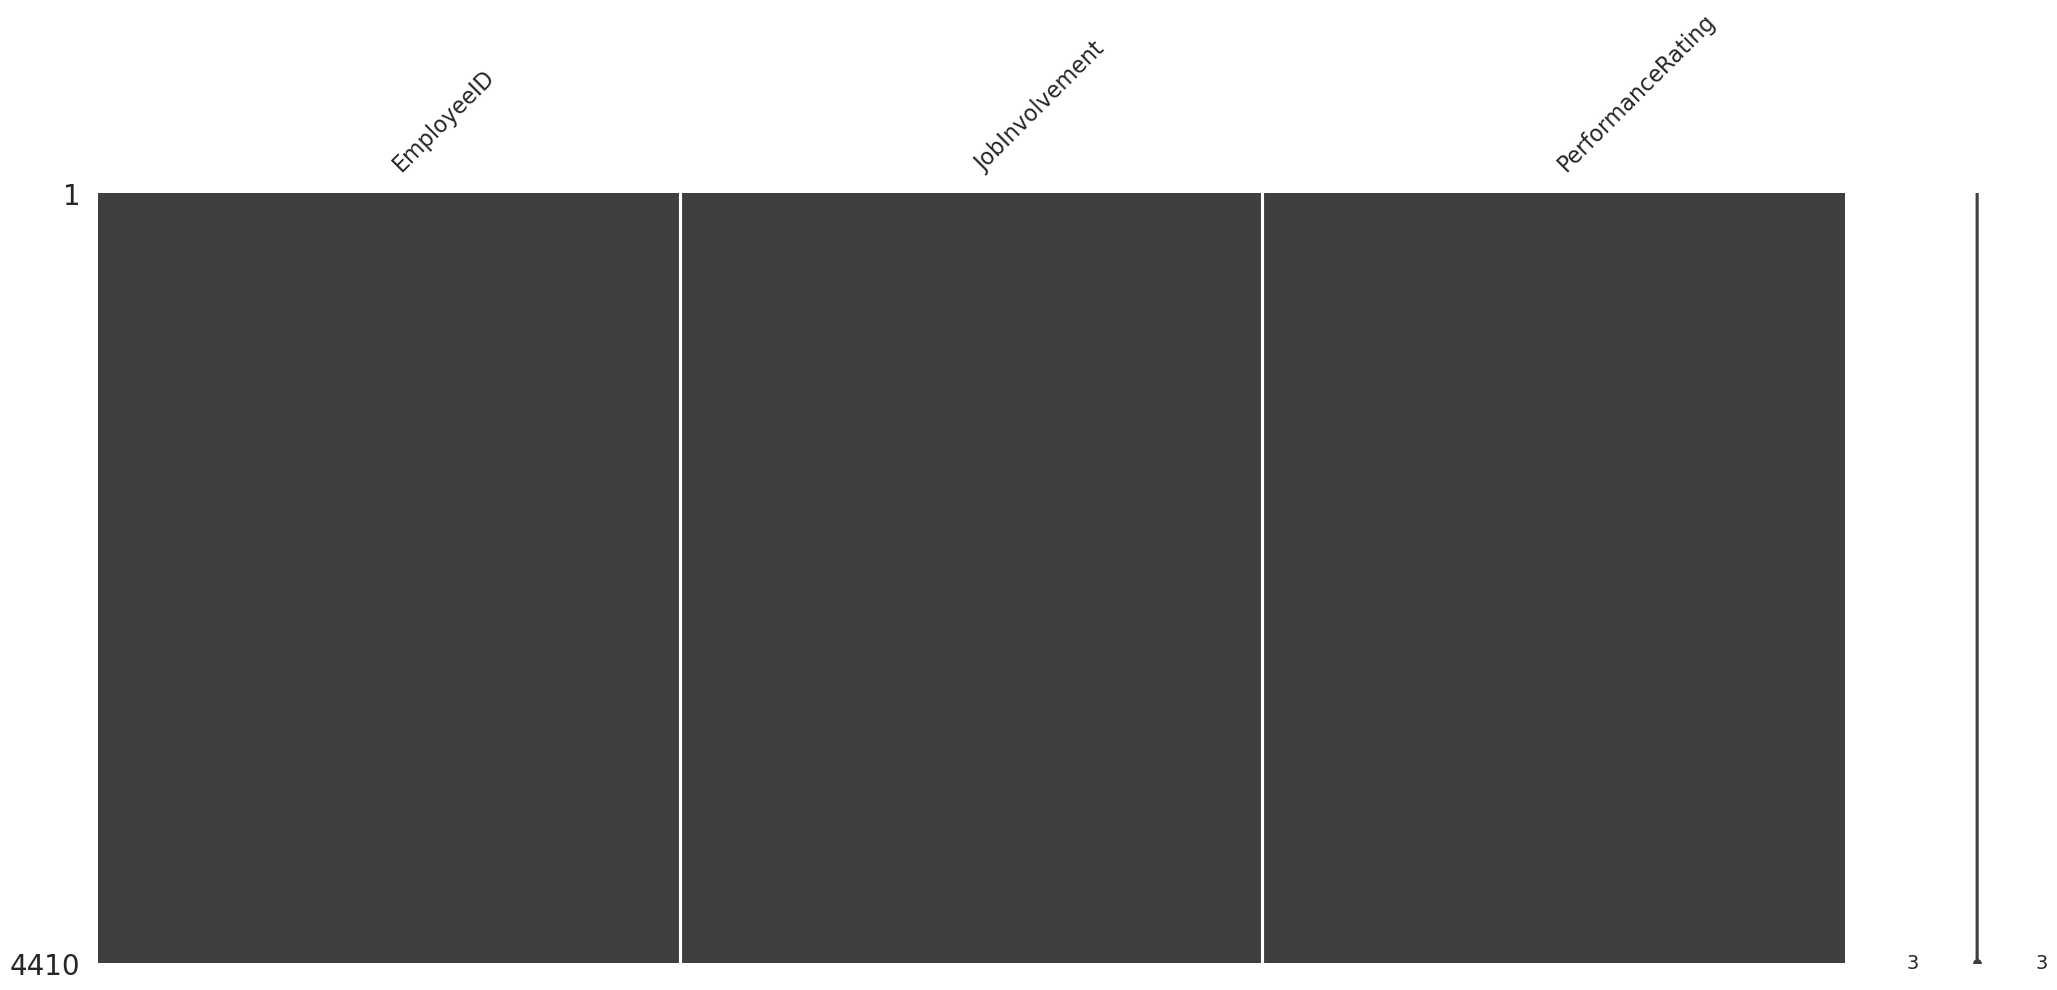

EmployeeID           0
JobInvolvement       0
PerformanceRating    0
dtype: int64

In [21]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing data
msno.matrix(manager_survey_data)
plt.show()

# Impute missing values
# For numerical columns, use median imputation
numerical_columns = manager_survey_data.select_dtypes(include=['float64', 'int64']).columns
manager_survey_data[numerical_columns] = manager_survey_data[numerical_columns].fillna(manager_survey_data[numerical_columns].median())

# Verify that there are no more missing values
manager_survey_data.isnull().sum()


Traitement du dataset in_time_data et out_time_data

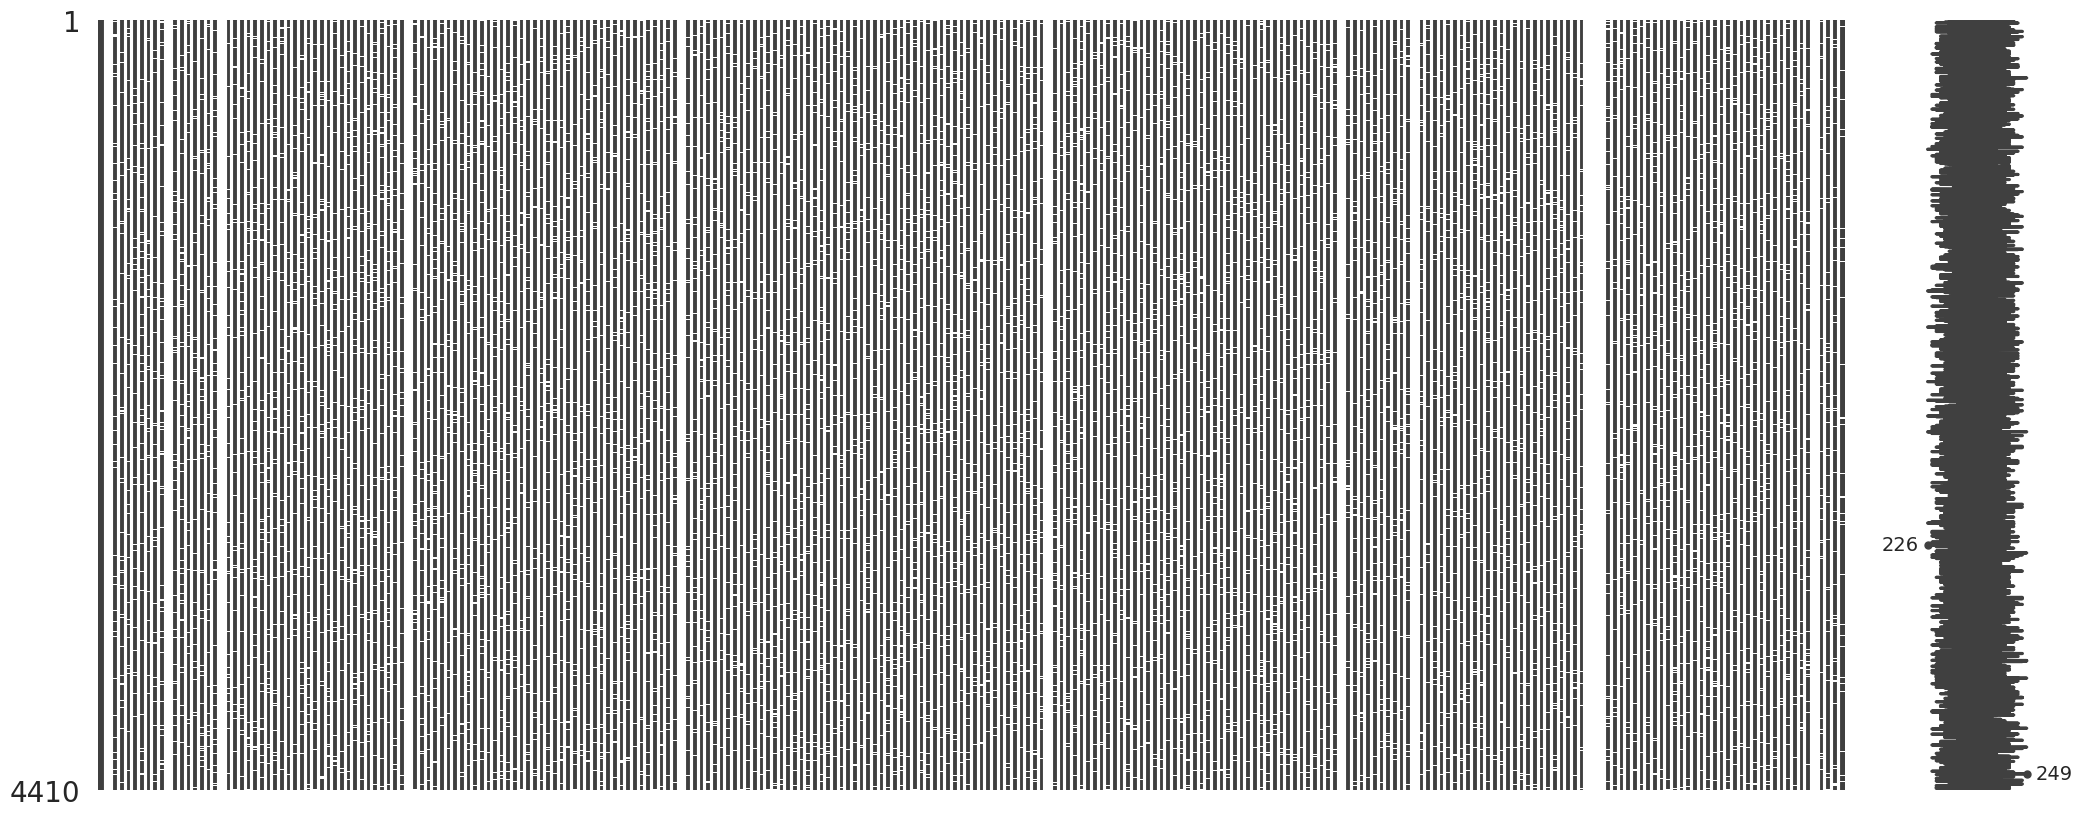

EmployeeID       0
2015-01-01    4410
2015-01-02       0
2015-01-05       0
2015-01-06       0
              ... 
2015-12-25    4410
2015-12-28       0
2015-12-29       0
2015-12-30       0
2015-12-31       0
Length: 262, dtype: int64

In [50]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing data
msno.matrix(in_time_data)
plt.show()

# Impute missing values
# For numerical columns, use median imputation
numerical_columns = in_time_data.select_dtypes(include=['float64', 'int64']).columns
in_time_data[numerical_columns] = in_time_data[numerical_columns].fillna(in_time_data[numerical_columns].median())

# For categorical columns, use mode imputation
categorical_columns = in_time_data.select_dtypes(include=['object']).columns
in_time_data[categorical_columns] = in_time_data[categorical_columns].fillna(in_time_data[categorical_columns].mode().iloc[0])

# Verify that there are no more missing values
in_time_data.isnull().sum()


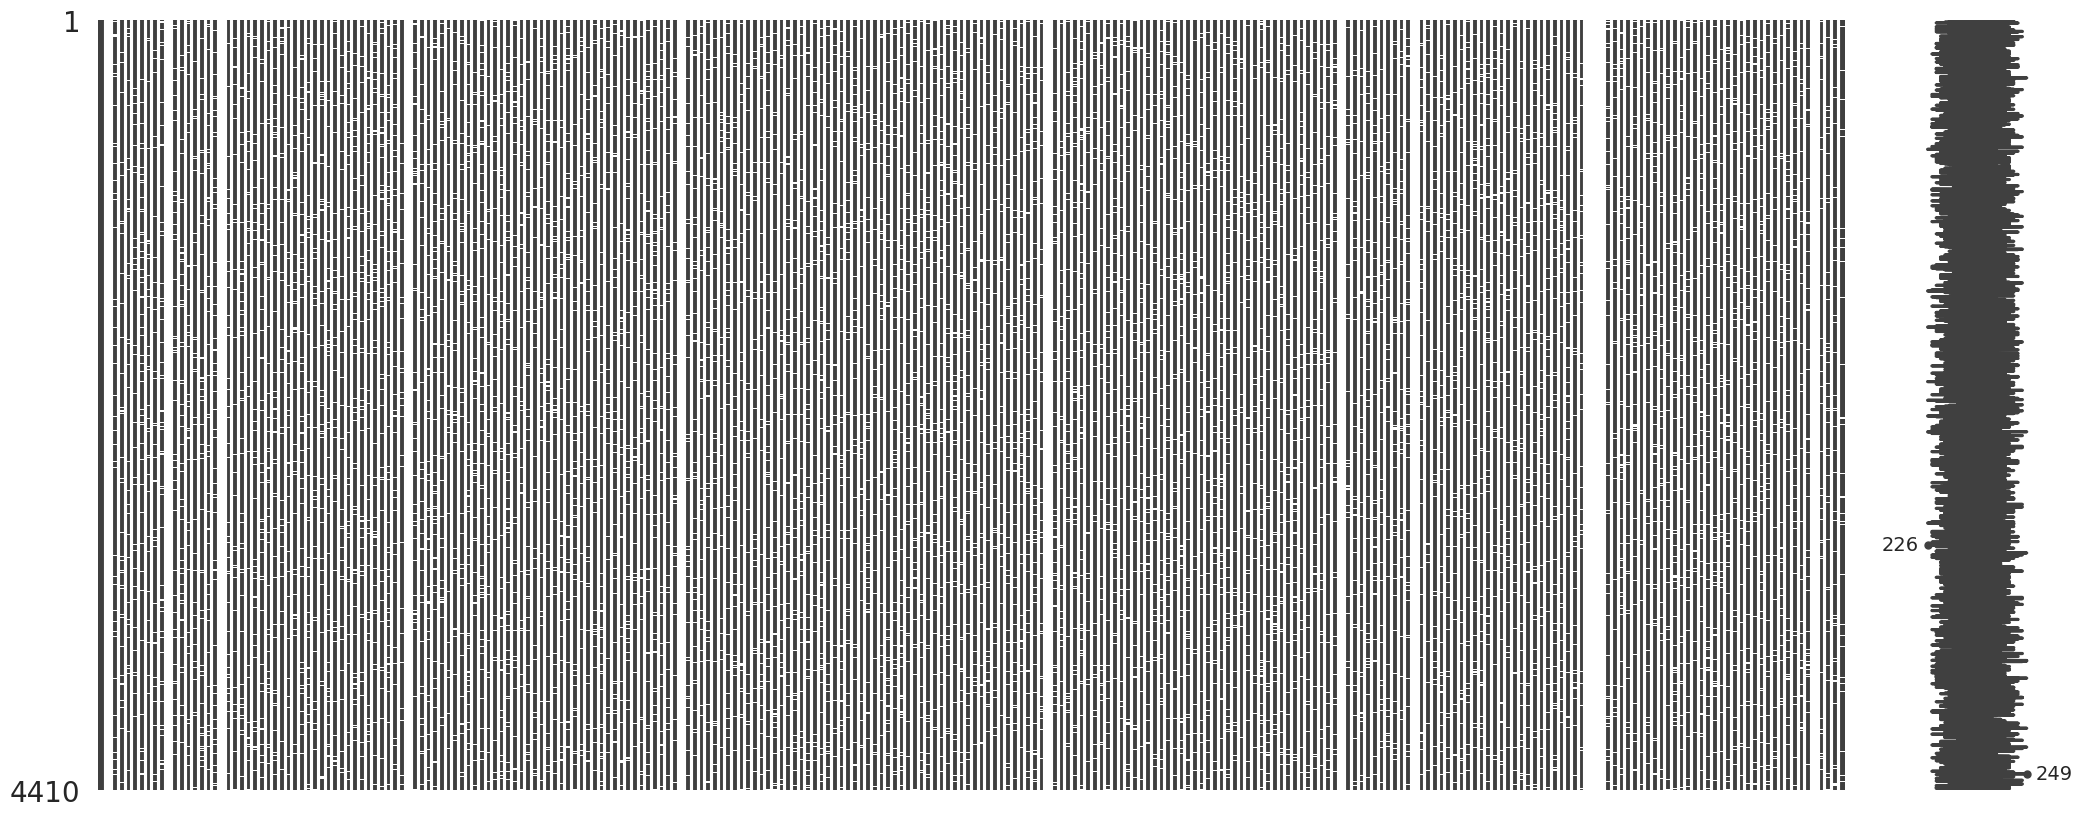

EmployeeID       0
2015-01-01    4410
2015-01-02       0
2015-01-05       0
2015-01-06       0
              ... 
2015-12-25    4410
2015-12-28       0
2015-12-29       0
2015-12-30       0
2015-12-31       0
Length: 262, dtype: int64

In [51]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing data
msno.matrix(out_time_data)
plt.show()

# Impute missing values
# For numerical columns, use median imputation
numerical_columns = out_time_data.select_dtypes(include=['float64', 'int64']).columns
out_time_data[numerical_columns] = out_time_data[numerical_columns].fillna(out_time_data[numerical_columns].median())

# For categorical columns, use mode imputation
categorical_columns = out_time_data.select_dtypes(include=['object']).columns
out_time_data[categorical_columns] = out_time_data[categorical_columns].fillna(out_time_data[categorical_columns].mode().iloc[0])

# Verify that there are no more missing values
out_time_data.isnull().sum()

Jointure des datasets

In [52]:
datasets = [employee_survey_data, general_data, manager_survey_data, in_time_data, out_time_data]
merged_data = reduce(lambda left, right: pd.merge(left, right, on='EmployeeID', how='outer'), datasets)
merged_data.head()



,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating,2015-01-01_x,2015-01-02_x,2015-01-05_x,2015-01-06_x,2015-01-07_x,2015-01-08_x,2015-01-09_x,2015-01-12_x,2015-01-13_x,2015-01-14_x,2015-01-15_x,2015-01-16_x,2015-01-19_x,2015-01-20_x,2015-01-21_x,2015-01-22_x,2015-01-23_x,2015-01-26_x,2015-01-27_x,2015-01-28_x,2015-01-29_x,2015-01-30_x,2015-02-02_x,2015-02-03_x,2015-02-04_x,2015-02-05_x,2015-02-06_x,2015-02-09_x,2015-02-10_x,2015-02-11_x,2015-02-12_x,2015-02-13_x,2015-02-16_x,2015-02-17_x,2015-02-18_x,2015-02-19_x,2015-02-20_x,2015-02-23_x,2015-02-24_x,2015-02-25_x,2015-02-26_x,2015-02-27_x,2015-03-02_x,2015-03-03_x,2015-03-04_x,2015-03-05_x,2015-03-06_x,2015-03-09_x,2015-03-10_x,2015-03-11_x,2015-03-12_x,2015-03-13_x,2015-03-16_x,2015-03-17_x,2015-03-18_x,2015-03-19_x,2015-03-20_x,2015-03-23_x,2015-03-24_x,2015-03-25_x,2015-03-26_x,2015-03-27_x,2015-03-30_x,2015-03-31_x,2015-04-01_x,2015-04-02_x,2015-04-03_x,2015-04-06_x,2015-04-07_x,2015-04-08_x,2015-04-09_x,2015-04-10_x,2015-04-13_x,2015-04-14_x,2015-04-15_x,2015-04-16_x,2015-04-17_x,2015-04-20_x,2015-04-21_x,2015-04-22_x,2015-04-23_x,2015-04-24_x,2015-04-27_x,2015-04-28_x,2015-04-29_x,2015-04-30_x,2015-05-01_x,2015-05-04_x,2015-05-05_x,2015-05-06_x,2015-05-07_x,2015-05-08_x,2015-05-11_x,2015-05-12_x,2015-05-13_x,2015-05-14_x,2015-05-15_x,2015-05-18_x,2015-05-19_x,2015-05-20_x,2015-05-21_x,2015-05-22_x,2015-05-25_x,2015-05-26_x,2015-05-27_x,2015-05-28_x,2015-05-29_x,2015-06-01_x,2015-06-02_x,2015-06-03_x,2015-06-04_x,2015-06-05_x,2015-06-08_x,2015-06-09_x,2015-06-10_x,2015-06-11_x,2015-06-12_x,2015-06-15_x,2015-06-16_x,2015-06-17_x,2015-06-18_x,2015-06-19_x,2015-06-22_x,2015-06-23_x,2015-06-24_x,2015-06-25_x,2015-06-26_x,2015-06-29_x,2015-06-30_x,2015-07-01_x,2015-07-02_x,2015-07-03_x,2015-07-06_x,2015-07-07_x,2015-07-08_x,2015-07-09_x,2015-07-10_x,2015-07-13_x,2015-07-14_x,2015-07-15_x,2015-07-16_x,2015-07-17_x,2015-07-20_x,2015-07-21_x,2015-07-22_x,2015-07-23_x,2015-07-24_x,2015-07-27_x,2015-07-28_x,2015-07-29_x,2015-07-30_x,2015-07-31_x,2015-08-03_x,2015-08-04_x,2015-08-05_x,2015-08-06_x,2015-08-07_x,2015-08-10_x,2015-08-11_x,2015-08-12_x,2015-08-13_x,2015-08-14_x,2015-08-17_x,2015-08-18_x,2015-08-19_x,2015-08-20_x,2015-08-21_x,2015-08-24_x,2015-08-25_x,2015-08-26_x,2015-08-27_x,2015-08-28_x,2015-08-31_x,2015-09-01_x,2015-09-02_x,2015-09-03_x,2015-09-04_x,2015-09-07_x,2015-09-08_x,2015-09-09_x,2015-09-10_x,2015-09-11_x,2015-09-14_x,2015-09-15_x,2015-09-16_x,2015-09-17_x,2015-09-18_x,2015-09-21_x,2015-09-22_x,2015-09-23_x,2015-09-24_x,2015-09-25_x,2015-09-28_x,2015-09-29_x,2015-09-30_x,2015-10-01_x,2015-10-02_x,2015-10-05_x,2015-10-06_x,2015-10-07_x,2015-10-08_x,2015-10-09_x,2015-10-12_x,2015-10-13_x,2015-10-14_x,2015-10-15_x,2015-10-16_x,2015-10-19_x,2015-10-20_x,2015-10-21_x,2015-10-22_x,2015-10-23_x,2015-10-26_x,2015-10-27_x,2015-10-28_x,2015-10-29_x,2015-10-30_x,2015-11-02_x,2015-11-03_x,2015-11-04_x,2015-11-05_x,2015-11-06_x,2015-11-09_x,2015-11-10_x,2015-11-11_x,2015-11-12_x,2015-11-13_x,2015-11-16_x,2015-11-17_x,2015-11-18_x,2015-11-19_x,2015-11-20_x,2015-11-23_x,2015-11-24_x,2015-11-25_x,2015-11-26_x,2015-11-27_x,2015-11-30_x,2015-12-01_x,2015-12-02_x,2015-12-03_x,2015-12-04_x,2015-12-07_x,2015-12-08_x,2015-12-09_x,2015-12-10_x,2015-12-11_x,2015-12-14_x,2015-12-15_x,2015-12-16_x,2015-12-17_x,2015-12-18_x,2015-12-21_x,2015-12-22_x,2015-12-23_x,2015-12-24_x,2015-12-25_x,2015-12-28_x,2015-12-29_x,2015-12-30_x,2015-12-31_x,2015-01-01_y,2015-01-02_y,2015-01-05_y,2015-01-06_y,2015-01-07_y,2015-01-08_y,2015-01-09_y,2015-01-12_y,2015-01-13_y,2015-01-14_y,2015-01-15_y,2015-01-16_y,2015-01-19_y,2015-01-20_y,2

Analyse univariée et bivariée

In [ ]:
# Univariate analysis for numerical features
for column in numerical_columns:
        plt.figure(figsize=(10, 4))
        sns.histplot(merged_data_data[column], kde=True)
        plt.title(f'Distribution of {column}')
        plt.show()
    # à compléter
    # à compléter

# Univariate analysis for categorical features
for column in categorical_columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=merged_data[column])
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)
    plt.show()